In [189]:
"""Perform feature engineering, scaling and pipeline"""
from scipy.stats import skew,gaussian_kde
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [190]:
file_path="data_scaling_skewed_data.csv"

#To read csv file
df=pd.read_csv(file_path)

In [191]:
df.head()

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
0,1,4.79,25,68.22,26401.83,5.13,68.46
1,2,2.99,25,72.62,29899.43,10.14,58.53
2,3,2.76,24,87.15,84956.82,6.63,50.72
3,4,2.76,20,87.14,15797.16,0.99,72.44
4,5,9.30,18,87.15,44019.48,2.10,60.92


In [192]:
df.shape

(100, 7)

In [193]:
df.dtypes

Student_ID                int64
Study_Hours             float64
Age                       int64
Attendance              float64
Family_Income           float64
Internet_Usage_Hours    float64
Exam_Score              float64
dtype: object

In [194]:
df.columns

Index(['Student_ID', 'Study_Hours', 'Age', 'Attendance', 'Family_Income',
       'Internet_Usage_Hours', 'Exam_Score'],
      dtype='str')

In [195]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            100 non-null    int64  
 1   Study_Hours           100 non-null    float64
 2   Age                   100 non-null    int64  
 3   Attendance            97 non-null     float64
 4   Family_Income         100 non-null    float64
 5   Internet_Usage_Hours  98 non-null     float64
 6   Exam_Score            100 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 5.6 KB


In [196]:
df.describe()

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
count,100.000000,100.000000,100.000000,97.000000,100.000000,98.000000,100.000000
mean,50.500000,3.838400,21.670000,81.819588,40416.447600,2.971837,67.884100
std,29.011492,2.453124,2.395513,9.957090,37941.665524,2.842141,11.554282
min,1.000000,0.430000,18.000000,49.590000,3977.840000,0.050000,40.340000
25%,25.750000,2.180000,20.000000,75.380000,15954.600000,0.765000,59.675000
50%,50.500000,3.395000,22.000000,82.640000,27459.915000,2.165000,67.640000
75%,75.250000,4.810000,24.000000,88.620000,47944.172500,3.900000,76.387500
max,100.000000,14.600000,25.000000,100.000000,193072.810000,13.700000,94.900000


In [197]:
df.duplicated().sum()

np.int64(0)

In [198]:
df.isna().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              3
Family_Income           0
Internet_Usage_Hours    2
Exam_Score              0
dtype: int64

In [199]:
df.isnull().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              3
Family_Income           0
Internet_Usage_Hours    2
Exam_Score              0
dtype: int64

In [200]:
df[["Attendance", "Internet_Usage_Hours"]].describe()

,Attendance,Internet_Usage_Hours
count,97.000000,98.000000
mean,81.819588,2.971837
std,9.957090,2.842141
min,49.590000,0.050000
25%,75.380000,0.765000
50%,82.640000,2.165000
75%,88.620000,3.900000
max,100.000000,13.700000


In [201]:
from sklearn.impute import SimpleImputer

In [202]:
imputer = SimpleImputer(strategy="median")

In [203]:
X = df.drop(columns=["Exam_Score", "Student_ID"])
y = df["Exam_Score"]

In [204]:
X.head()

,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours
0,4.79,25,68.22,26401.83,5.13
1,2.99,25,72.62,29899.43,10.14
2,2.76,24,87.15,84956.82,6.63
3,2.76,20,87.14,15797.16,0.99
4,9.30,18,87.15,44019.48,2.10


In [205]:
X.shape

(100, 5)

In [206]:
y.head()

0    68.46
1    58.53
2    50.72
3    72.44
4    60.92
Name: Exam_Score, dtype: float64

In [207]:
y.shape

(100,)

In [208]:
from sklearn.compose import ColumnTransformer

numerical_impute_columns = [
    "Attendance",
    "Internet_Usage_Hours"
]

In [209]:
trf1 = ColumnTransformer([("impute_numerical",SimpleImputer(strategy="median"),numerical_impute_columns)],remainder="passthrough",verbose_feature_names_out=False).set_output(transform="pandas")

In [210]:
from sklearn.base import BaseEstimator,TransformerMixin

In [211]:
df_imputed = trf1.fit_transform(df)

In [212]:
df_imputed.isnull().sum()

Attendance              0
Internet_Usage_Hours    0
Student_ID              0
Study_Hours             0
Age                     0
Family_Income           0
Exam_Score              0
dtype: int64

In [213]:
df.skew(numeric_only=True)

Student_ID              0.000000
Study_Hours             1.466644
Age                    -0.104205
Attendance             -0.271046
Family_Income           2.242351
Internet_Usage_Hours    1.474339
Exam_Score              0.038566
dtype: float64

In [214]:
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 500x600 with 0 Axes>

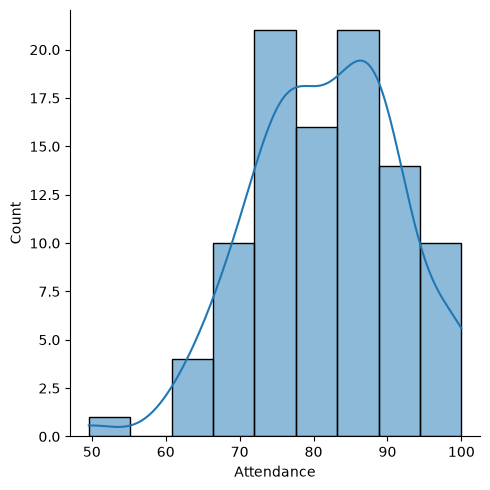

<Figure size 500x600 with 0 Axes>

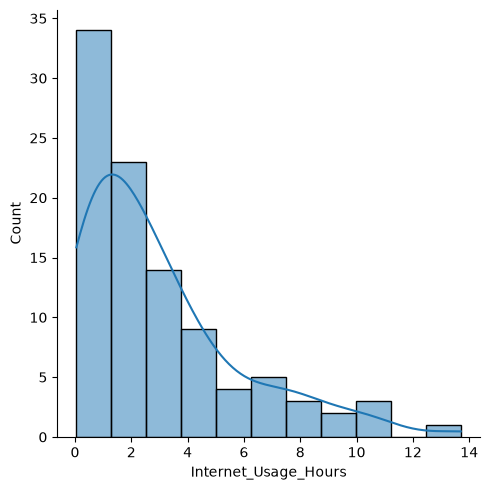

In [215]:
for col in numerical_impute_columns:
    plt.figure(figsize=(5,6))
    sns.displot(df[col],kde=True)
    plt.show()

In [216]:
df_log = df.copy()

In [217]:
df_log["Study_Hours"] = np.log(df_log["Study_Hours"])

In [218]:
df_log["Study_Hours"].head()

0    1.566530
1    1.095273
2    1.015231
3    1.015231
4    2.230014
Name: Study_Hours, dtype: float64

In [219]:
df["Study_Hours"].head()

0    4.79
1    2.99
2    2.76
3    2.76
4    9.30
Name: Study_Hours, dtype: float64

In [220]:
print(df["Study_Hours"].skew())
print(df_log["Study_Hours"].skew())

1.4666435421156974
-0.5767398597896658


In [221]:
df_log["Family_Income"] = np.log(df_log["Family_Income"])
df_log["Family_Income"].skew()

np.float64(0.20074452738019943)

In [222]:
df_log["Internet_Usage_Hours"] = np.log(
    df_log["Internet_Usage_Hours"]
)

In [223]:
print(df_log["Internet_Usage_Hours"].skew())
print(df["Internet_Usage_Hours"].skew())

-0.6317467627200353
1.474338979727393


In [224]:
print("Original skewness:")
print(df[
    ["Study_Hours", "Family_Income", "Internet_Usage_Hours"]
].skew())

print("\nLog transformed skewness:")
print(df_log[
    ["Study_Hours", "Family_Income", "Internet_Usage_Hours"]
].skew())

Original skewness:
Study_Hours             1.466644
Family_Income           2.242351
Internet_Usage_Hours    1.474339
dtype: float64

Log transformed skewness:
Study_Hours            -0.576740
Family_Income           0.200745
Internet_Usage_Hours   -0.631747
dtype: float64


In [225]:
df_log1p = df.copy()

In [226]:
skewed_columns = [
    "Study_Hours",
    "Family_Income",
    "Internet_Usage_Hours"
]

for column in skewed_columns:
    df_log1p[column] = np.log1p(df_log1p[column])

In [227]:
print("Original:")
print(df[skewed_columns].skew())

print("\nLog:")
print(df_log[skewed_columns].skew())

print("\nLog1p:")
print(df_log1p[skewed_columns].skew())

Original:
Study_Hours             1.466644
Family_Income           2.242351
Internet_Usage_Hours    1.474339
dtype: float64

Log:
Study_Hours            -0.576740
Family_Income           0.200745
Internet_Usage_Hours   -0.631747
dtype: float64

Log1p:
Study_Hours            -0.009842
Family_Income           0.200835
Internet_Usage_Hours    0.269164
dtype: float64


In [228]:
np.sqrt(X)

,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours
0,2.188607,5.000000,8.259540,162.486399,2.264950
1,1.729162,5.000000,8.521737,172.914516,3.184337
2,1.661325,4.898979,9.335416,291.473532,2.574879
3,1.661325,4.472136,9.334881,125.686753,0.994987
4,3.049590,4.242641,9.335416,209.808198,1.449138
...,...,...,...,...,...
95,1.345362,5.000000,9.396808,286.293451,1.009950
96,3.292416,4.242641,8.585453,80.038491,2.090454
97,2.170253,4.242641,8.740709,125.246198,2.810694
98,1.183216,4.472136,9.458858,164.409398,1.584298


In [229]:
df_sqrt = df.copy()

In [230]:
skewed_columns = [
    "Study_Hours",
    "Family_Income",
    "Internet_Usage_Hours"
]
for column in skewed_columns:
    df_sqrt[column] = np.sqrt(df_sqrt[column])

In [231]:
df_sqrt[skewed_columns].skew()

Study_Hours             0.460007
Family_Income           1.246750
Internet_Usage_Hours    0.557342
dtype: float64

In [232]:
print("Original:")
print(df[skewed_columns].skew())

print("\nLog:")
print(df_log[skewed_columns].skew())

print("\nLog1p:")
print(df_log1p[skewed_columns].skew())

print("\nSquare Root:")
print(df_sqrt[skewed_columns].skew())

Original:
Study_Hours             1.466644
Family_Income           2.242351
Internet_Usage_Hours    1.474339
dtype: float64

Log:
Study_Hours            -0.576740
Family_Income           0.200745
Internet_Usage_Hours   -0.631747
dtype: float64

Log1p:
Study_Hours            -0.009842
Family_Income           0.200835
Internet_Usage_Hours    0.269164
dtype: float64

Square Root:
Study_Hours             0.460007
Family_Income           1.246750
Internet_Usage_Hours    0.557342
dtype: float64


In [233]:
from scipy.stats import yeojohnson

df_yeo = df_imputed.copy()

In [234]:
skewed_columns = [
    "Study_Hours",
    "Family_Income",
    "Internet_Usage_Hours"
]

In [235]:
lambdas = {}

for column in skewed_columns:
    df_yeo[column], lmbda = yeojohnson(df_yeo[column])
    lambdas[column] = lmbda

In [236]:
lambdas

{'Study_Hours': np.float64(0.007217082807872859),
 'Family_Income': np.float64(-0.09042077087823212),
 'Internet_Usage_Hours': np.float64(-0.21023457240227725)}

In [237]:
df_yeo[skewed_columns].skew()

Study_Hours            -0.000214
Family_Income           0.005131
Internet_Usage_Hours    0.043115
dtype: float64

In [238]:
print("Original:")
print(df[skewed_columns].skew())

print("\nLog:")
print(df_log[skewed_columns].skew())

print("\nLog1p:")
print(df_log1p[skewed_columns].skew())

print("\nSquare Root:")
print(df_sqrt[skewed_columns].skew())

print("\nYeo-Johnson:")
print(df_yeo[skewed_columns].skew())

Original:
Study_Hours             1.466644
Family_Income           2.242351
Internet_Usage_Hours    1.474339
dtype: float64

Log:
Study_Hours            -0.576740
Family_Income           0.200745
Internet_Usage_Hours   -0.631747
dtype: float64

Log1p:
Study_Hours            -0.009842
Family_Income           0.200835
Internet_Usage_Hours    0.269164
dtype: float64

Square Root:
Study_Hours             0.460007
Family_Income           1.246750
Internet_Usage_Hours    0.557342
dtype: float64

Yeo-Johnson:
Study_Hours            -0.000214
Family_Income           0.005131
Internet_Usage_Hours    0.043115
dtype: float64


In [239]:
from sklearn.preprocessing import MinMaxScaler

numeric_features = [
    "Study_Hours",
    "Age",
    "Attendance",
    "Family_Income",
    "Internet_Usage_Hours"
]

In [240]:
scaler = MinMaxScaler()
df_scaled = df_imputed.copy()

In [241]:
df_scaled[numeric_features] = scaler.fit_transform(
    df_scaled[numeric_features]
)

In [242]:
df_scaled.head()

,Attendance,Internet_Usage_Hours,Student_ID,Study_Hours,Age,Family_Income,Exam_Score
0,0.369570,0.372161,1,0.307692,1.000000,0.118586,68.46
1,0.456854,0.739194,2,0.180663,1.000000,0.137082,58.53
2,0.745090,0.482051,3,0.164432,0.857143,0.428245,50.72
3,0.744892,0.068864,4,0.164432,0.285714,0.062505,72.44
4,0.745090,0.150183,5,0.625970,0.000000,0.211754,60.92


In [243]:
df_scaled[numeric_features].min()

Study_Hours             0.0
Age                     0.0
Attendance              0.0
Family_Income           0.0
Internet_Usage_Hours    0.0
dtype: float64

In [244]:
df_scaled[numeric_features].max()

Study_Hours             1.0
Age                     1.0
Attendance              1.0
Family_Income           1.0
Internet_Usage_Hours    1.0
dtype: float64

In [245]:
print("Minimum:")
print(df_scaled[numeric_features].min())

print("\nMaximum:")
print(df_scaled[numeric_features].max())

Minimum:
Study_Hours             0.0
Age                     0.0
Attendance              0.0
Family_Income           0.0
Internet_Usage_Hours    0.0
dtype: float64

Maximum:
Study_Hours             1.0
Age                     1.0
Attendance              1.0
Family_Income           1.0
Internet_Usage_Hours    1.0
dtype: float64


In [246]:
impute_features = [
    "Attendance",
    "Internet_Usage_Hours"
]

yeo_features = [
    "Study_Hours",
    "Family_Income",
    "Internet_Usage_Hours"
]

numeric_features = [
    "Study_Hours",
    "Age",
    "Attendance",
    "Family_Income",
    "Internet_Usage_Hours"
]

In [247]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

trf_imputer = ColumnTransformer(
    [
        (
            "imputation",
            SimpleImputer(strategy="median"),
            impute_features
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
).set_output(transform="pandas")

In [248]:
df_test = trf_imputer.fit_transform(df)

In [249]:
df_test.head()

,Attendance,Internet_Usage_Hours,Student_ID,Study_Hours,Age,Family_Income,Exam_Score
0,68.22,5.13,1,4.79,25,26401.83,68.46
1,72.62,10.14,2,2.99,25,29899.43,58.53
2,87.15,6.63,3,2.76,24,84956.82,50.72
3,87.14,0.99,4,2.76,20,15797.16,72.44
4,87.15,2.10,5,9.30,18,44019.48,60.92


In [250]:
df_test.isnull().sum()

Attendance              0
Internet_Usage_Hours    0
Student_ID              0
Study_Hours             0
Age                     0
Family_Income           0
Exam_Score              0
dtype: int64

In [251]:
from sklearn.preprocessing import PowerTransformer

trf_yeo = ColumnTransformer(
    [
        (
            "yeo_johnson",
            PowerTransformer(method="yeo-johnson"),
            yeo_features
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
).set_output(transform="pandas")

In [252]:
from sklearn.preprocessing import MinMaxScaler

trf_scaler = ColumnTransformer(
    [
        (
            "scaling",
            MinMaxScaler(),
            numeric_features
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
).set_output(transform="pandas")

In [253]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("imputation", trf_imputer),
    ("yeo_johnson", trf_yeo),
    ("scaling", trf_scaler)
])

In [254]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputation', ...), ('yeo_johnson', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputation', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_ou